In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

The data set we would be using,
Distance column (mm) is the distance between the ultrasonic sensor and the trash
- Height of bin should be 2000mm.
- NOTE: readings from the firebase for distance should be given as a percentage compared to the bin's height and would be entered as the feature: distance_percentage

**PART 1: DATA PREPARATION**

In [ ]:
df = pd.read_csv("data.csv")
print(df.dtypes)
display(df.head())
print(df.shape)

dev_id          object
time            object
temperature    float64
distance       float64
fillLevel      float64
battery        float64
Lat Long        object
Sensor Name     object
fill_level     float64
dtype: object


,dev_id,time,temperature,distance,fillLevel,battery,Lat Long,Sensor Name,fill_level
0,r718x-6f0b,2024-10-13T15:02:04+11:00,22.7,468.0,40.0,3.6,"-37.8020809, 144.9654563",r718x-bin sensor 14,35.0
1,r718x-6f10,2024-10-13T14:03:40+11:00,22.7,202.0,89.0,3.6,NaN,NaN,72.0
2,r718x-6f31,2024-10-13T15:02:36+11:00,23.0,200.0,74.0,3.6,"-37.8022594, 144.9659489",r718x-bin sensor 19,72.0
3,r718x-6f10,2024-10-13T15:03:40+11:00,22.5,202.0,89.0,3.6,NaN,NaN,72.0
4,r718x-6f0b,2024-10-06T15:01:58+11:00,22.5,65535.0,255.0,3.6,"-37.8020809, 144.9654563",r718x-bin sensor 14,-8877.0


(803348, 9)


In [ ]:
df[["Lat", "Long"]] = df["Lat Long"].str.split(",", expand=True)
df = df.drop("Lat Long", axis = 1)
df.head()

,dev_id,time,temperature,distance,fillLevel,battery,Sensor Name,fill_level,Lat,Long
0,r718x-6f0b,2024-10-13T15:02:04+11:00,22.7,468.0,40.0,3.6,r718x-bin sensor 14,35.0,-37.8020809,144.9654563
1,r718x-6f10,2024-10-13T14:03:40+11:00,22.7,202.0,89.0,3.6,NaN,72.0,NaN,NaN
2,r718x-6f31,2024-10-13T15:02:36+11:00,23.0,200.0,74.0,3.6,r718x-bin sensor 19,72.0,-37.8022594,144.9659489
3,r718x-6f10,2024-10-13T15:03:40+11:00,22.5,202.0,89.0,3.6,NaN,72.0,NaN,NaN
4,r718x-6f0b,2024-10-06T15:01:58+11:00,22.5,65535.0,255.0,3.6,r718x-bin sensor 14,-8877.0,-37.8020809,144.9654563


**Taking care of Null values, by deleting all of them**

In [ ]:
df.isnull().sum()


,0
dev_id,0
time,0
temperature,51
distance,51
fillLevel,51
battery,51
Sensor Name,102294
fill_level,51
Lat,102294
Long,102294


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().values.any()

np.False_

In [ ]:
df.shape

(701008, 10)

In [ ]:
df.describe()

,temperature,distance,fillLevel,battery,fill_level
count,701008.000000,701008.000000,701008.000000,701008.000000,701008.000000
mean,17.878618,1098.089779,77.536850,3.599952,-50.875208
std,5.336483,7349.350806,35.065771,0.002179,1006.662225
min,2.100000,199.000000,0.000000,3.500000,-8877.000000
25%,14.000000,201.000000,63.000000,3.600000,59.000000
50%,17.700000,206.000000,74.000000,3.600000,71.000000
75%,22.100000,297.000000,86.000000,3.600000,72.000000
max,52.800000,65535.000000,255.000000,3.600000,72.000000


**Finding how many fillLevel numbers are greater than 100 and taking appropriate actions to ensure fillLevel is between 0 and 100.**

In [ ]:
#finding how many fillLevel numbers are greater than 100
df[df["fillLevel"] > 100]["fillLevel"].unique()

array([255.])

In [ ]:
# Filter where fillLevel is 255
df_fillLevel_255 = df[df["fillLevel"] == 255]

# Get value counts of 'distance' in that subset
dist_counts_fill255 = df_fillLevel_255["distance"].value_counts()
dist_counts_fill255

,count
distance,
255.0,13545
65535.0,8993


In [ ]:
# Get overall counts for specific distance values
val_255 = df[df["distance"] == 255]["distance"].count()
val_65535 = df[df["distance"] == 65535]["distance"].count()

# Compare counts
print(dist_counts_fill255.get(255, 0) == val_255)
print(dist_counts_fill255.get(65535, 0) == val_65535)

False
True


In [ ]:
#checking how many values of distance = 255 was wrong
df[df["distance"] == 255]["fillLevel"].value_counts()

,count
fillLevel,
255.0,13545
67.0,83
87.0,17


In [ ]:
#dropping all rows with fill level = 255
df = df.drop(df[df["fillLevel"] == 255].index)

**Making the classification label column, "Needs_collection"**

In [ ]:
df["Needs_collection"] = np.where(df["fillLevel"] >=80, 1, 0)
df.head()


,dev_id,time,temperature,distance,fillLevel,battery,Sensor Name,fill_level,Lat,Long,Needs_collection
0,r718x-6f0b,2024-10-13T15:02:04+11:00,22.7,468.0,40.0,3.6,r718x-bin sensor 14,35.0,-37.8020809,144.9654563,0
2,r718x-6f31,2024-10-13T15:02:36+11:00,23.0,200.0,74.0,3.6,r718x-bin sensor 19,72.0,-37.8022594,144.9659489,0
5,r718x-6f34,2024-10-06T14:59:48+11:00,23.5,201.0,74.0,3.6,r718x-bin sensor 20,72.0,-37.802165,144.9661423,0
7,r718x-6f0b,2024-09-22T03:16:45+10:00,19.8,461.0,41.0,3.6,r718x-bin sensor 14,36.0,-37.8020809,144.9654563,0
8,r718x-6f34,2024-09-22T03:14:40+10:00,21.0,202.0,74.0,3.6,r718x-bin sensor 20,72.0,-37.802165,144.9661423,0


**Fill Level Categorization**
  
Empty: fillLevel < 10%

Low: 10% ≤ fillLevel < 40%

Medium: 40% ≤ fillLevel < 80%

Full: fillLevel ≥ 80%

In [ ]:
def categorize_fill_level(level):
    if level < 10:
        return 'Empty'
    elif level < 40:
        return 'Low'
    elif level < 80:
        return 'Medium'
    else:
        return 'Full'

# Apply the function to the fillLevel column
df['fill_category'] = df['fillLevel'].apply(categorize_fill_level)

# Optional: check distribution
print(df['fill_category'].value_counts())

fill_category
Medium    504828
Full      161769
Low         9263
Empty       2610
Name: count, dtype: int64


**Finding and deleting rows where the values in a column named "distance" are above the bin height = 2000,**

In [ ]:
df = df[df["distance"] <= 2000]
print(df.shape)
df.head()


(676877, 12)


,dev_id,time,temperature,distance,fillLevel,battery,Sensor Name,fill_level,Lat,Long,Needs_collection,fill_category
0,r718x-6f0b,2024-10-13T15:02:04+11:00,22.7,468.0,40.0,3.6,r718x-bin sensor 14,35.0,-37.8020809,144.9654563,0,Medium
2,r718x-6f31,2024-10-13T15:02:36+11:00,23.0,200.0,74.0,3.6,r718x-bin sensor 19,72.0,-37.8022594,144.9659489,0,Medium
5,r718x-6f34,2024-10-06T14:59:48+11:00,23.5,201.0,74.0,3.6,r718x-bin sensor 20,72.0,-37.802165,144.9661423,0,Medium
7,r718x-6f0b,2024-09-22T03:16:45+10:00,19.8,461.0,41.0,3.6,r718x-bin sensor 14,36.0,-37.8020809,144.9654563,0,Medium
8,r718x-6f34,2024-09-22T03:14:40+10:00,21.0,202.0,74.0,3.6,r718x-bin sensor 20,72.0,-37.802165,144.9661423,0,Medium


In [ ]:
df.describe()

,temperature,distance,fillLevel,battery,fill_level,Needs_collection
count,676877.000000,676877.000000,676877.000000,676877.000000,676877.000000,676877.000000
mean,17.729129,250.299236,71.810332,3.599952,65.239303,0.238993
std,5.360127,82.743985,13.336853,0.002194,11.327178,0.426469
min,2.100000,199.000000,0.000000,3.500000,-173.000000,0.000000
25%,13.700000,201.000000,63.000000,3.600000,59.000000,0.000000
50%,17.400000,204.000000,74.000000,3.600000,72.000000,0.000000
75%,21.800000,294.000000,74.000000,3.600000,72.000000,0.000000
max,52.800000,1998.000000,90.000000,3.600000,72.000000,1.000000


In [ ]:
#Checking to ensure the fill level and distance actually make sense
df_max_distance = df[df["distance"] == 1998]
df_max_distance

,dev_id,time,temperature,distance,fillLevel,battery,Sensor Name,fill_level,Lat,Long,Needs_collection,fill_category
584643,r718x-6f13,2024-08-06T12:38:04+10:00,21.8,1998.0,0.0,3.6,r718x-bin sensor 16,-173.0,-37.8028815,144.9662607,0,Empty


Converting distance measurements to percentages to allow the model to function correctly regardless of the bin’s height (2000)

In [ ]:
df["distance_percentage"] = (df["distance"] / 2000) * 100

**Working on the Time Column**

In [ ]:
#Convert the time column to datetime format,UTC, and change any invalid timestamp to NaN
df["time"] = pd.to_datetime(df["time"], utc=True,errors="coerce")
invalid_timestamps = df[df["time"].isna()]
print(invalid_timestamps) #If there are no nan values it should ouput Empty DataFrame

#Count how many duplicated datapoints there might be:
num_duplicates = df.duplicated(subset=["dev_id", "time"]).sum()
print(f"Number of duplicate rows: {num_duplicates}")

Empty DataFrame
Columns: [dev_id, time, temperature, distance, fillLevel, battery, Sensor Name, fill_level, Lat, Long, Needs_collection, fill_category, distance_percentage]
Index: []
Number of duplicate rows: 0


**Explanation of the timestamp:**
E.g: 2024-10-13  04:02:04 +00:00

*   The date: October 13, 2024
*   The time: 4:02 AM and 4 seconds

*   The timezone offset: UTC



In [ ]:
df.head()

,dev_id,time,temperature,distance,fillLevel,battery,Sensor Name,fill_level,Lat,Long,Needs_collection,fill_category,distance_percentage
0,r718x-6f0b,2024-10-13 04:02:04+00:00,22.7,468.0,40.0,3.6,r718x-bin sensor 14,35.0,-37.8020809,144.9654563,0,Medium,23.40
2,r718x-6f31,2024-10-13 04:02:36+00:00,23.0,200.0,74.0,3.6,r718x-bin sensor 19,72.0,-37.8022594,144.9659489,0,Medium,10.00
5,r718x-6f34,2024-10-06 03:59:48+00:00,23.5,201.0,74.0,3.6,r718x-bin sensor 20,72.0,-37.802165,144.9661423,0,Medium,10.05
7,r718x-6f0b,2024-09-21 17:16:45+00:00,19.8,461.0,41.0,3.6,r718x-bin sensor 14,36.0,-37.8020809,144.9654563,0,Medium,23.05
8,r718x-6f34,2024-09-21 17:14:40+00:00,21.0,202.0,74.0,3.6,r718x-bin sensor 20,72.0,-37.802165,144.9661423,0,Medium,10.10


In [ ]:
#Getting more features for the model
df["month"] = df["time"].dt.month
df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.weekday
df["is_weekend"] = df["day_of_week"] >= 5
df["is_weekend"] = df["is_weekend"].astype(int)


Explanation:


*   .dt.hour: extracts the hour (0–23)
*   .dt.weekday: returns 0 for Monday through 6 for Sunday
*   .dt.month: extracts the month (1 -12)
*   `>= 5: flags Saturday (5) and Sunday (6) as weekend

**Adding Seasons Feature**: using the seasons for Australia since that's were the data was gotten from

*   Summer: December to february
*   Autumn: March - May
*   Winter: June - August
*   Spring: September - November



In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    elif month in [9, 10, 11]:
        return "Spring"
    else:
        return None  # In case of missing month

# Apply the function
df["season"] = df["month"].apply(get_season)

**Checking for any errors in the Latitude and Longitude part**

In [ ]:
#checking to ensure all values are between -90 and 90 for latitude
df["Lat"].unique()

array(['-37.8020809', '-37.8022594', '-37.802165', '-37.8028815',
       '-37.8027498', '-37.8032344', '-37.8028794', '-37.8026209',
       '-37.8032959', '-37.8032085', '-37.8031969', '-37.8022434',
       '-37.8025943', '-37.8022471', '-37.8028672', '-37.8021666',
       '-37.8021852', '-37.8026257', '-37.8032818', '-37.8025769',
       '-37.8021051'], dtype=object)

In [ ]:
#checking to ensure all values are between -180 and 180 for longitude
df["Long"].unique()

array([' 144.9654563', ' 144.9659489', ' 144.9661423', ' 144.9662607',
       ' 144.9664732', ' 144.9663926', ' 144.9662728', ' 144.9660728',
       ' 144.9661516', ' 144.9652622', ' 144.9652732', ' 144.9657104',
       ' 144.9658434', ' 144.9665562', ' 144.9657946', ' 144.9661648',
       ' 144.9665057', ' 144.9652423', ' 144.9661258', ' 144.9656557',
       ' 144.9654523'], dtype=object)

In [ ]:
#Sort the time in descending order (newest to oldest)
df = df.sort_values(by="time", ascending=False).reset_index(drop=True)
df.head()

,dev_id,time,temperature,distance,fillLevel,battery,Sensor Name,fill_level,Lat,Long,Needs_collection,fill_category,distance_percentage,month,hour,day_of_week,is_weekend,season
0,r718x-6771,2025-06-08 03:58:03+00:00,16.9,202.0,89.0,3.6,r718x-bin sensor 4,72.0,-37.8032085,144.9652622,1,Full,10.10,6,3,6,1,Winter
1,r718x-6f06,2025-06-08 03:54:20+00:00,16.8,204.0,89.0,3.6,r718x-bin sensor 13,72.0,-37.8032959,144.9661516,1,Full,10.20,6,3,6,1,Winter
2,r718x-6774,2025-06-08 03:48:27+00:00,17.1,203.0,89.0,3.6,r718x-bin sensor 6,72.0,-37.8032344,144.9663926,1,Full,10.15,6,3,6,1,Winter
3,r718x-676b,2025-06-08 03:43:47+00:00,16.6,202.0,74.0,3.6,r718x-bin sensor 1,72.0,-37.8027498,144.9664732,0,Medium,10.10,6,3,6,1,Winter
4,r718x-6f0b,2025-06-08 03:35:55+00:00,17.2,269.0,65.0,3.6,r718x-bin sensor 14,63.0,-37.8020809,144.9654563,0,Medium,13.45,6,3,6,1,Winter


In [ ]:
df["month"].unique()

array([ 6,  5,  4,  3,  2,  1, 12, 11, 10,  9,  8,  7], dtype=int32)

In [ ]:
df.columns

Index(['dev_id', 'time', 'temperature', 'distance', 'fillLevel', 'battery',
       'Sensor Name', 'fill_level', 'Lat', 'Long', 'Needs_collection',
       'fill_category', 'distance_percentage', 'month', 'hour', 'day_of_week',
       'is_weekend', 'season'],
      dtype='object')

In [ ]:
df['dev_id'].nunique()

21






**PART 2: TRAINING THE VARIOUS MODELS**

In [ ]:
import time
import joblib
import os
# Prepare features for collection prediction
feature_cols = ['fillLevel', 'distance_percentage', 'hour', 'day_of_week', 'temperature',
                'month', 'is_weekend']

# Encode categorical variables
le_season = LabelEncoder()
df_ml = df.copy()
df_ml['season_encoded'] = le_season.fit_transform(df['season'])
feature_cols.append('season_encoded')

X = df_ml[feature_cols]
y = df_ml['Needs_collection']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Train models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'Random Forest':
        start_time = time.time()
        model.fit(X_train, y_train)
        end_time = time.time()
        execution_time = end_time - start_time
        # Training Accuracy
        train_accuracy = accuracy_score(y_train, model.predict(X_train))
        print(f"Training Accuracy: {train_accuracy:.3f}")

        # Cross-Validation
        from sklearn.model_selection import cross_val_score
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)
        print(f"5-Fold CV Score: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

        # Feature Importance
        importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
        print("\nFeature Importances:")
        print(importances.head(5))  # Top 5 features

        print(f"\n{name} Execution Time: {execution_time:.2f} seconds")
        y_pred = model.predict(X_test)

        joblib.dump(model, 'random_forest_model.pkl')
        rf_size = os.path.getsize('random_forest_model.pkl') / 1024  # Size in KB
        print(f"Random Forest Model Size: {rf_size:.2f} KB")

    else:
        start_time = time.time()
        model.fit(X_train_scaled, y_train)
        end_time = time.time()
        # Training Accuracy
        train_accuracy = accuracy_score(y_train, model.predict(X_train_scaled))
        print(f"Training Accuracy: {train_accuracy:.3f}")

        # Cross-Validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
        print(f"5-Fold CV Score: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

        # Coefficients
        coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
        print("\nLogistic Regression Coefficients:")
        print(coefficients)

        execution_time = end_time - start_time
        print(f"\n{name} Execution Time: {execution_time:.2f} seconds")
        y_pred = model.predict(X_test_scaled)
        joblib.dump(model, 'logistic_regression_model.pkl')
        logreg_size = os.path.getsize('logistic_regression_model.pkl') / 1024  # Size in KB
        print(f"Logistic Regression Model Size: {logreg_size:.2f} KB")

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    # Save scaler
    joblib.dump(scaler, 'scaler.pkl')
    scaler_size = os.path.getsize('scaler.pkl') / 1024
    print(f"Scaler Size: {scaler_size:.2f} KB")

    # Save label encoder
    joblib.dump(le_season, 'label_encoder.pkl')
    encoder_size = os.path.getsize('label_encoder.pkl') / 1024
    print(f"Label Encoder Size: {encoder_size:.2f} KB")


    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.3f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    c_m = confusion_matrix(y_test, y_pred, labels=[True, False])
    print(f"\nConfusion Matrix for {name}")
    cm_df = pd.DataFrame(
    c_m,
    index=['Actual: True', 'Actual: False'],
    columns=['Predicted: True', 'Predicted: False'])
    print(cm_df)


Training Accuracy: 1.000
5-Fold CV Score: 1.00 ± 0.00

Feature Importances:
fillLevel              0.862690
distance_percentage    0.084207
temperature            0.036434
month                  0.008640
season_encoded         0.006939
dtype: float64

Random Forest Execution Time: 20.19 seconds
Random Forest Model Size: 1523.32 KB
Scaler Size: 1.13 KB
Label Encoder Size: 0.50 KB

Random Forest Results:
Accuracy: 1.000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103161
           1       1.00      1.00      1.00     32215

    accuracy                           1.00    135376
   macro avg       1.00      1.00      1.00    135376
weighted avg       1.00      1.00      1.00    135376


Confusion Matrix for Random Forest
               Predicted: True  Predicted: False
Actual: True             32215                 0
Actual: False                0            103161
Training Accuracy: 1.000
5-Fold CV Score: 1.0

**PART 3: VISUALIZATION OF FEATURES**

In [ ]:
df_ml.drop(columns=["dev_id", "time","season","fill_category"])

df

,dev_id,time,temperature,distance,fillLevel,battery,Sensor Name,fill_level,Lat,Long,Needs_collection,fill_category,distance_percentage,month,hour,day_of_week,is_weekend,season
0,r718x-6771,2025-06-08 03:58:03+00:00,16.9,202.0,89.0,3.6,r718x-bin sensor 4,72.0,-37.8032085,144.9652622,1,Full,10.10,6,3,6,1,Winter
1,r718x-6f06,2025-06-08 03:54:20+00:00,16.8,204.0,89.0,3.6,r718x-bin sensor 13,72.0,-37.8032959,144.9661516,1,Full,10.20,6,3,6,1,Winter
2,r718x-6774,2025-06-08 03:48:27+00:00,17.1,203.0,89.0,3.6,r718x-bin sensor 6,72.0,-37.8032344,144.9663926,1,Full,10.15,6,3,6,1,Winter
3,r718x-676b,2025-06-08 03:43:47+00:00,16.6,202.0,74.0,3.6,r718x-bin sensor 1,72.0,-37.8027498,144.9664732,0,Medium,10.10,6,3,6,1,Winter
4,r718x-6f0b,2025-06-08 03:35:55+00:00,17.2,269.0,65.0,3.6,r718x-bin sensor 14,63.0,-37.8020809,144.9654563,0,Medium,13.45,6,3,6,1,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676872,r718x-6f16,2023-02-26 08:18:10+00:00,19.9,202.0,74.0,3.6,r718x-bin sensor 17,72.0,-37.8028794,144.9662728,0,Medium,10.10,2,8,6,1,Summer
676873,r718x-677d,2023-02-26 08:18:02+00:00,20.7,200.0,74.0,3.6,r718x-bin sensor 11,72.0,-37.8021051,144.9654523,0,Medium,10.00,2,8,6,1,Summer
676874,r718x-6773,2023-02-26 08:18:02+00:00,19.1,228.0,70.0,3.6,r718x-bin sensor 5,68.0,-37.8022471,144.9665562,0,Medium,11.40,2,8,6,1,Summer
676875,r718x-6778,2023-02-26 08:16:47+00:00,19.0,209.0,73.0,3.6,r718x-bin sensor 8,71.0,-37.8025943,144.9658434,0,Medium,10.45,2,8,6,1,Summer


In [ ]:
df = df.drop(columns=["Sensor Name"], axis=1)

# df.columns

In [ ]:
df_ml.drop(columns=["dev_id", "time","Sensor Name", "season","fill_category"]).corr()


,temperature,distance,fillLevel,battery,fill_level,Lat,Long,Needs_collection,distance_percentage,month,hour,day_of_week,is_weekend,season_encoded
temperature,1.000000,-0.139919,0.237530,0.046795,0.139545,-0.043814,0.010538,0.229896,-0.139919,0.008465,-0.333210,-0.021663,-0.022402,-0.113359
distance,-0.139919,1.000000,-0.811158,-0.001634,-0.999756,-0.025521,-0.019063,-0.279157,1.000000,-0.025112,-0.008905,-0.001210,0.012012,-0.029134
fillLevel,0.237530,-0.811158,1.000000,0.008104,0.811688,-0.100718,-0.140221,0.726182,-0.811158,0.086864,0.006616,0.003415,-0.007073,0.059214
battery,0.046795,-0.001634,0.008104,1.000000,0.001617,0.003826,-0.006697,0.012144,-0.001634,0.000885,-0.024062,0.011471,0.006364,-0.023745
fill_level,0.139545,-0.999756,0.811688,0.001617,1.000000,0.025668,0.018958,0.279056,-0.999756,0.024340,0.009067,0.001026,-0.012151,0.029527
Lat,-0.043814,-0.025521,-0.100718,0.003826,0.025668,1.000000,0.043981,-0.276031,-0.025521,-0.045008,0.000249,-0.003277,-0.000548,-0.020650
Long,0.010538,-0.019063,-0.140221,-0.006697,0.018958,0.043981,1.000000,-0.286583,-0.019063,0.025397,-0.004529,-0.000569,-0.001514,0.023098
Needs_collection,0.229896,-0.279157,0.726182,0.012144,0.279056,-0.276031,-0.286583,1.000000,-0.279157,0.100839,0.000758,0.003791,0.002365,0.071512
distance_percentage,-0.139919,1.000000,-0.811158,-0.001634,-0.999756,-0.025521,-0.019063,-0.279157,1.000000,-0.025112,-0.008905,-0.001210,0.012012,-0.029134
month,0.008465,-0.025112,0.086864,0.000885,0.024340,-0.045008,0.025397,0.100839,-0.025112,1.000000,0.002904,0.019271,0.012634,0.226113


📊 DATASET OVERVIEW
Dataset Shape: (676877, 17)
Date Range: 2023-02-26 08:16:37+00:00 to 2025-06-08 03:58:03+00:00
Number of Bins: 21

📈 BASIC STATISTICS
         temperature       distance      fillLevel        battery  \
count  676877.000000  676877.000000  676877.000000  676877.000000   
mean       17.729129     250.299236      71.810332       3.599952   
std         5.360127      82.743985      13.336853       0.002194   
min         2.100000     199.000000       0.000000       3.500000   
25%        13.700000     201.000000      63.000000       3.600000   
50%        17.400000     204.000000      74.000000       3.600000   
75%        21.800000     294.000000      74.000000       3.600000   
max        52.800000    1998.000000      90.000000       3.600000   

          fill_level  Needs_collection  distance_percentage          month  \
count  676877.000000     676877.000000        676877.000000  676877.000000   
mean       65.239303          0.238993            12.514962       6.6

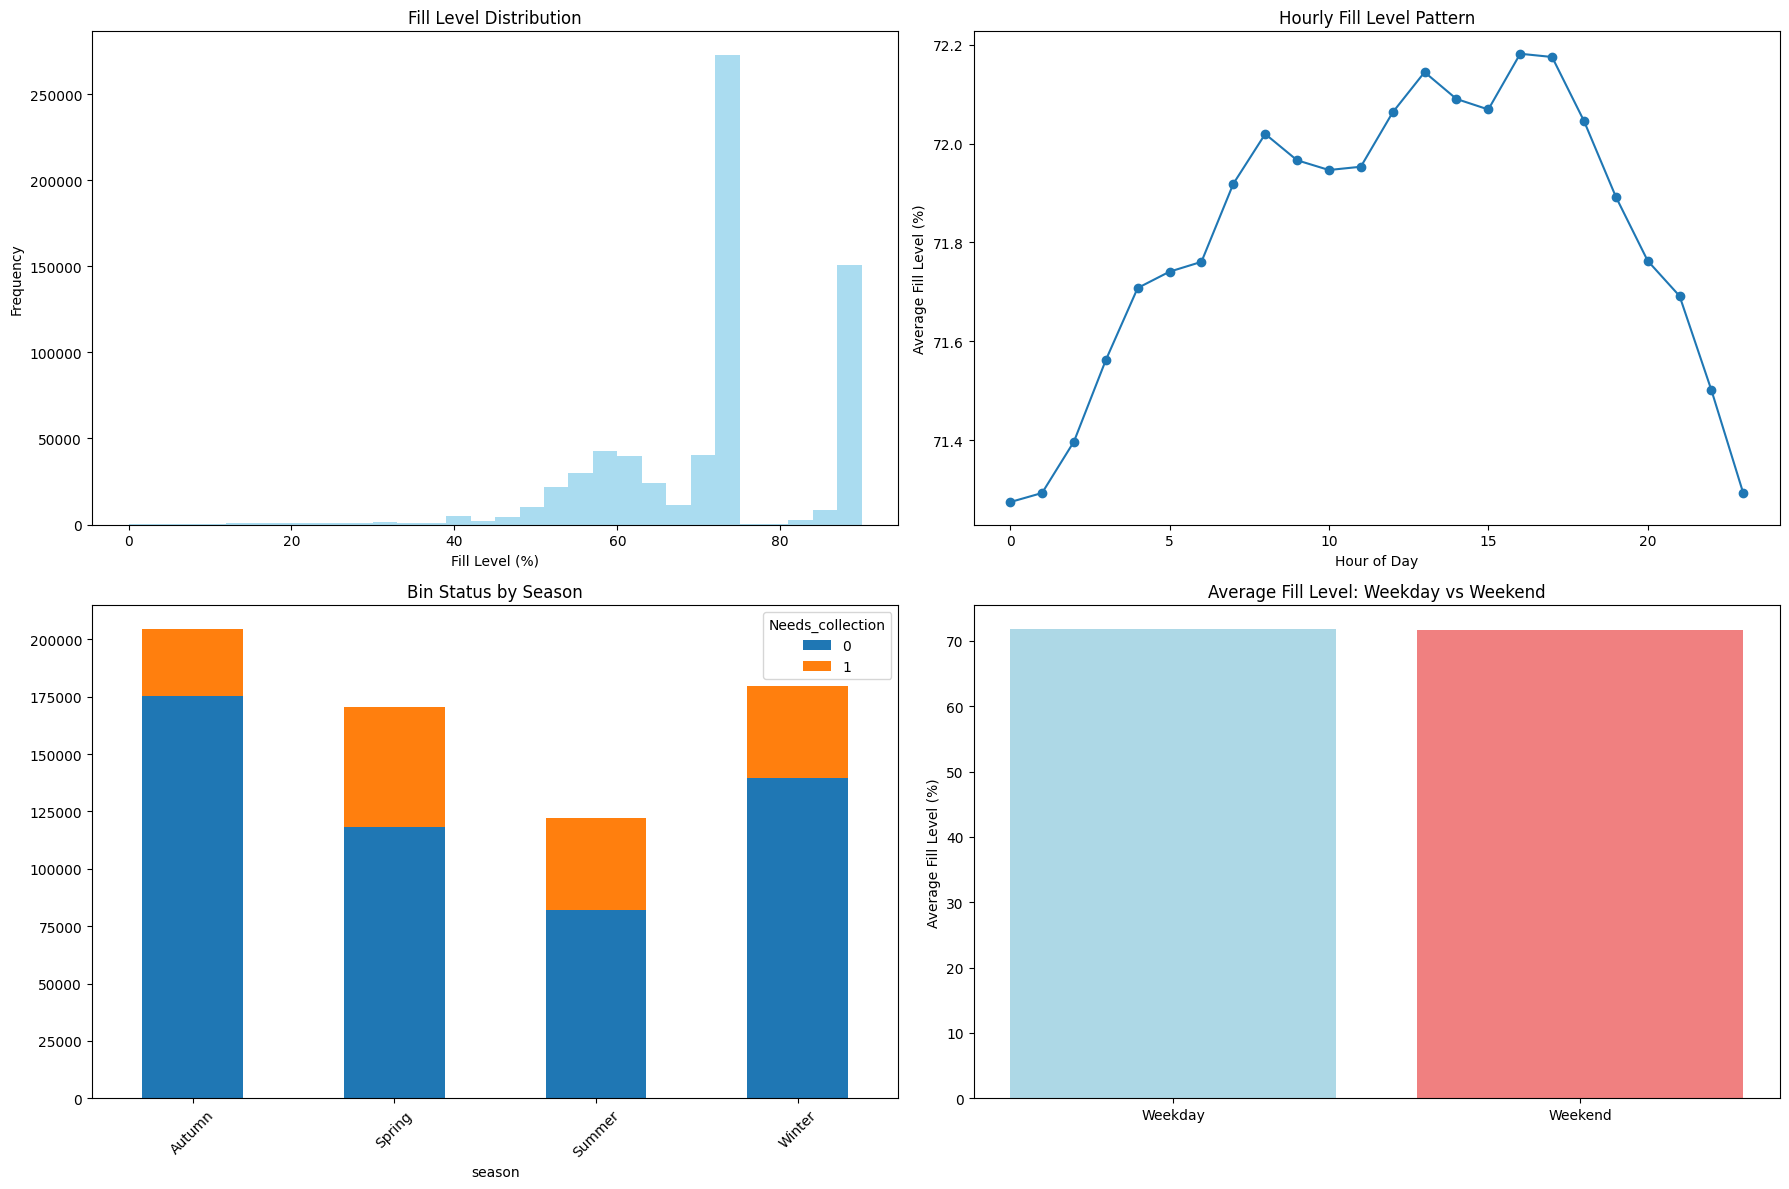

In [ ]:
print("📊 DATASET OVERVIEW")
print("="*50)
print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['time'].min()} to {df['time'].max()}")
print(f"Number of Bins: {df['dev_id'].nunique()}")

print("\n📈 BASIC STATISTICS")
print(df.describe())

print("\n🗑️ BIN STATUS DISTRIBUTION")
print(df['Needs_collection'].value_counts())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Fill Level Distribution
axes[0,0].hist(df['fillLevel'], bins=30, alpha=0.7, color='skyblue')
axes[0,0].set_title('Fill Level Distribution')
axes[0,0].set_xlabel('Fill Level (%)')
axes[0,0].set_ylabel('Frequency')


# Calculate average fill level by hour
hourly_usage = df.groupby('hour')['fillLevel'].mean()
axes[0, 1].plot(hourly_usage.index, hourly_usage.values, marker='o')
axes[0, 1].set_title('Hourly Fill Level Pattern')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Average Fill Level (%)')



# Bin Status by Season Type
status_location = pd.crosstab(df['season'], df['Needs_collection'])
status_location.plot(kind='bar', ax=axes[1,0], stacked=True)
axes[1,0].set_title('Bin Status by Season')
axes[1,0].tick_params(axis='x', rotation=45)


# Weekend vs Weekday Usage
weekend_data = df.groupby('is_weekend')['fillLevel'].mean()
axes[1,1].bar(['Weekday', 'Weekend'], weekend_data.values, color=['lightblue', 'lightcoral'])
axes[1,1].set_title('Average Fill Level: Weekday vs Weekend')
axes[1,1].set_ylabel('Average Fill Level (%)')

plt.tight_layout()
plt.show()


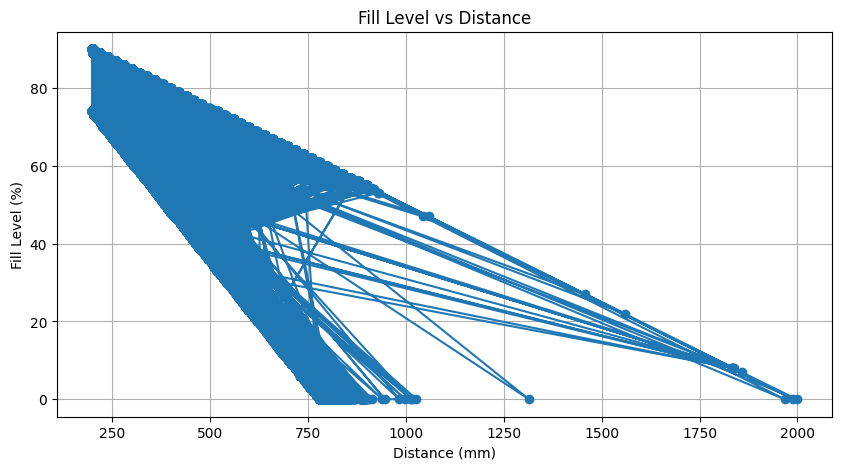

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['distance'], df['fillLevel'], marker='o', linestyle='-')
plt.title('Fill Level vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Fill Level (%)')
plt.grid(True)
plt.show()


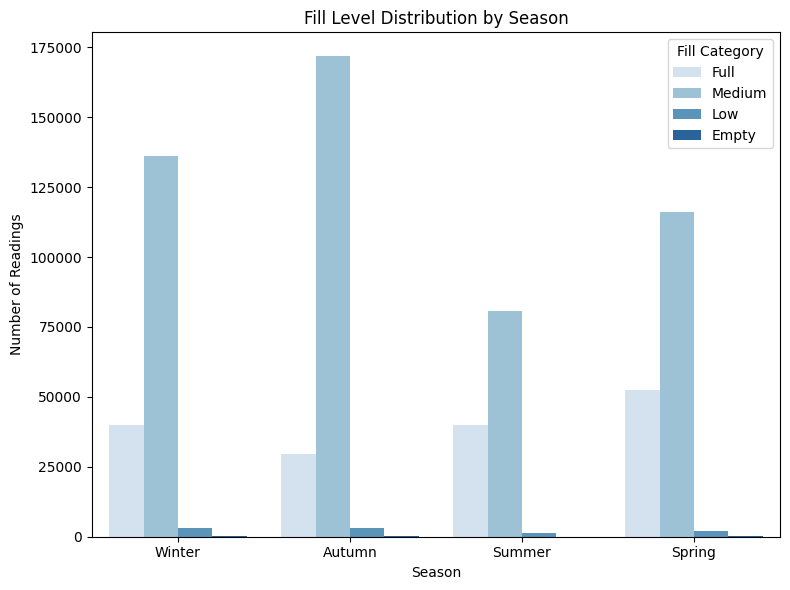

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='season', hue='fill_category', palette='Blues')

plt.title('Fill Level Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Number of Readings')
plt.legend(title='Fill Category')
plt.tight_layout()
plt.show()

PART5: PREDICTING IN HOW MANY HOURS IT WOULD TAKE FOR THE BIN TO FILL

In [ ]:
df.dtypes

In [ ]:
df_ml.dtypes

In [ ]:
df

,dev_id,time,temperature,distance,fillLevel,battery,fill_level,Lat,Long,Needs_collection,fill_category,distance_percentage,month,hour,day_of_week,is_weekend,season
0,r718x-6771,2025-06-08 03:58:03+00:00,16.9,202.0,89.0,3.6,72.0,-37.8032085,144.9652622,1,Full,10.10,6,3,6,1,Winter
1,r718x-6f06,2025-06-08 03:54:20+00:00,16.8,204.0,89.0,3.6,72.0,-37.8032959,144.9661516,1,Full,10.20,6,3,6,1,Winter
2,r718x-6774,2025-06-08 03:48:27+00:00,17.1,203.0,89.0,3.6,72.0,-37.8032344,144.9663926,1,Full,10.15,6,3,6,1,Winter
3,r718x-676b,2025-06-08 03:43:47+00:00,16.6,202.0,74.0,3.6,72.0,-37.8027498,144.9664732,0,Medium,10.10,6,3,6,1,Winter
4,r718x-6f0b,2025-06-08 03:35:55+00:00,17.2,269.0,65.0,3.6,63.0,-37.8020809,144.9654563,0,Medium,13.45,6,3,6,1,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676872,r718x-6f16,2023-02-26 08:18:10+00:00,19.9,202.0,74.0,3.6,72.0,-37.8028794,144.9662728,0,Medium,10.10,2,8,6,1,Summer
676873,r718x-677d,2023-02-26 08:18:02+00:00,20.7,200.0,74.0,3.6,72.0,-37.8021051,144.9654523,0,Medium,10.00,2,8,6,1,Summer
676874,r718x-6773,2023-02-26 08:18:02+00:00,19.1,228.0,70.0,3.6,68.0,-37.8022471,144.9665562,0,Medium,11.40,2,8,6,1,Summer
676875,r718x-6778,2023-02-26 08:16:47+00:00,19.0,209.0,73.0,3.6,71.0,-37.8025943,144.9658434,0,Medium,10.45,2,8,6,1,Summer


In [ ]:
from tqdm import tqdm

time_to_full_list = []
df = df.sort_values(['dev_id', 'time']).reset_index(drop=True)
# Iterate over each device (bin)
for dev_id, group in tqdm(df.groupby('dev_id')):
    group = group.reset_index(drop=True)
    times = group['time']
    fill_levels = group['fillLevel']

    time_to_full = []

    for i in range(len(group)):
        current_time = times[i]

        # Look ahead in future rows
        future_full = group.loc[i+1:]
        future_full = future_full[future_full['fillLevel'] >= 75]

        if not future_full.empty:
            time_when_full = future_full.iloc[0]['time']
            delta = (time_when_full - current_time).total_seconds() / 3600  # hours
        else:
            delta = None  # or set to a max value or drop later

        time_to_full.append(delta)

    time_to_full_list.extend(time_to_full)

# Add as a new column
df['time_to_full'] = time_to_full_list
df


100%|██████████| 21/21 [15:09<00:00, 43.32s/it]


,dev_id,time,temperature,distance,fillLevel,battery,fill_level,Lat,Long,Needs_collection,fill_category,distance_percentage,month,hour,day_of_week,is_weekend,season,time_to_full
0,r718x-676b,2023-02-26 09:05:59+00:00,18.7,215.0,72.0,3.6,70.0,-37.8027498,144.9664732,0,Medium,10.75,2,9,6,1,Summer,NaN
1,r718x-676b,2023-02-26 09:20:59+00:00,18.4,202.0,74.0,3.6,72.0,-37.8027498,144.9664732,0,Medium,10.10,2,9,6,1,Summer,NaN
2,r718x-676b,2023-02-26 09:35:59+00:00,18.3,219.0,72.0,3.6,70.0,-37.8027498,144.9664732,0,Medium,10.95,2,9,6,1,Summer,NaN
3,r718x-676b,2023-02-26 09:50:59+00:00,18.3,202.0,74.0,3.6,72.0,-37.8027498,144.9664732,0,Medium,10.10,2,9,6,1,Summer,NaN
4,r718x-676b,2023-02-26 10:05:59+00:00,18.2,251.0,68.0,3.6,65.0,-37.8027498,144.9664732,0,Medium,12.55,2,10,6,1,Summer,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676872,r718x-6f35,2023-08-21 09:35:41+00:00,16.4,202.0,74.0,3.6,72.0,-37.8021666,144.9661648,0,Medium,10.10,8,9,0,0,Winter,NaN
676873,r718x-6f35,2023-08-21 09:50:41+00:00,16.4,202.0,74.0,3.6,72.0,-37.8021666,144.9661648,0,Medium,10.10,8,9,0,0,Winter,NaN
676874,r718x-6f35,2023-08-21 10:05:41+00:00,16.0,202.0,74.0,3.6,72.0,-37.8021666,144.9661648,0,Medium,10.10,8,10,0,0,Winter,NaN
676875,r718x-6f35,2023-08-21 10:20:41+00:00,16.1,202.0,74.0,3.6,72.0,-37.8021666,144.9661648,0,Medium,10.10,8,10,0,0,Winter,NaN


In [ ]:
np.sum(df["time_to_full"].isnull(),axis = 0)

np.int64(375308)

In [ ]:
df_tmp = df[~df["time_to_full"].isnull()]

df_tmp[df_tmp["time_to_full"] <= 730].to_csv("final_data.csv", index=False)

In [ ]:
df_t = pd.read_csv("final_data.csv")
df_t

,dev_id,time,temperature,distance,fillLevel,battery,fill_level,Lat,Long,Needs_collection,fill_category,distance_percentage,month,hour,day_of_week,is_weekend,season,time_to_full
0,r718x-676c,2024-06-01 20:20:58+00:00,9.6,362.0,53.0,3.6,50.0,-37.803197,144.965273,0,Medium,18.10,6,20,5,1,Winter,729.898611
1,r718x-676c,2024-06-01 20:35:58+00:00,9.6,362.0,53.0,3.6,50.0,-37.803197,144.965273,0,Medium,18.10,6,20,5,1,Winter,729.648611
2,r718x-676c,2024-06-01 20:50:58+00:00,9.4,362.0,53.0,3.6,50.0,-37.803197,144.965273,0,Medium,18.10,6,20,5,1,Winter,729.398611
3,r718x-676c,2024-06-01 21:05:58+00:00,9.3,362.0,53.0,3.6,50.0,-37.803197,144.965273,0,Medium,18.10,6,21,5,1,Winter,729.148611
4,r718x-676c,2024-06-01 21:35:58+00:00,9.5,362.0,53.0,3.6,50.0,-37.803197,144.965273,0,Medium,18.10,6,21,5,1,Winter,728.648611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171814,r718x-6f25,2025-05-24 13:02:40+00:00,16.2,201.0,89.0,3.6,72.0,-37.802243,144.965710,1,Full,10.05,5,13,5,1,Autumn,40.497778
171815,r718x-6f25,2025-05-26 05:32:32+00:00,19.6,201.0,89.0,3.6,72.0,-37.802243,144.965710,1,Full,10.05,5,5,0,0,Autumn,27.252500
171816,r718x-6f25,2025-05-27 08:47:41+00:00,12.8,200.0,90.0,3.6,72.0,-37.802243,144.965710,1,Full,10.00,5,8,1,0,Autumn,17.000278
171817,r718x-6f25,2025-05-28 01:47:42+00:00,17.0,200.0,90.0,3.6,72.0,-37.802243,144.965710,1,Full,10.00,5,1,2,0,Autumn,31.998056


In [ ]:
df_tmp[df_tmp["time_to_full"] > 730].season.value_counts()

,count
season,
Autumn,57363
Winter,30868
Spring,22726
Summer,18793


In [ ]:
df.shape

In [ ]:
df[df['time_to_full'].notna()]


In [ ]:
grouped = df.groupby('dev_id')
group = grouped.get_group('r718x-676b')
group.head()

In [ ]:
group.shape

In [ ]:
first_full_times = grouped.apply(lambda g: g[g['fillLevel'] >= 75].head(1))
first_full_times = first_full_times.reset_index(drop=True)
first_full_times[first_full_times['dev_id'] == 'r718x-676b']


In [ ]:
#how many binstake more than a month (730 hrs) to be fill
over_month = df[df['time_to_full'] > 730]

# Count unique bins (dev_ids)
num_bins = over_month['dev_id'].nunique()
print(f"{num_bins} bins take over a month to be filled")
over_month['dev_id'].value_counts()


10 bins take over a month to be filled


,count
dev_id,
r718x-6f13,34835
r718x-676c,34340
r718x-6774,28745
r718x-6771,11680
r718x-6f25,10251
r718x-6773,4690
r718x-677d,4666
r718x-677a,539
r718x-6f0f,2


In [ ]:
#how many binstake more than a year (8760 hrs) to be fill
over_year = df[df['time_to_full'] > 8760]

# Count unique bins (dev_ids)
num_bins = over_year['dev_id'].nunique()
print(f"{num_bins} bins take over a year to be filled")
over_year['dev_id'].value_counts()



6 bins take over a year to be filled


,count
dev_id,
r718x-6f13,10854
r718x-676c,10656
r718x-6771,10519
r718x-6774,10056
r718x-6773,4689
r718x-677d,4666


In [ ]:
# number of bins that take more than a year to fill or  null values.
over_year = df['time_to_full'] > 8760
null_val = df['time_to_full'].isnull()
null_over_year = df[over_year | null_val]


# Count unique bins (dev_ids)
num_bins = null_over_year['dev_id'].nunique()
print(f"{num_bins} bins take over a year or have null values to be filled")
null_over_year['dev_id'].value_counts()

21 bins take over a year or have null values to be filled


,count
dev_id,
r718x-6f16,53305
r718x-676b,52535
r718x-6f34,45726
r718x-677c,35661
r718x-6f31,35407
r718x-6775,32513
r718x-6778,29851
r718x-677e,29606
r718x-676f,24389


=====================Model Training=====================

In [ ]:
df_use = pd.read_csv("final_data.csv")
df_use

,dev_id,time,temperature,distance,fillLevel,battery,fill_level,Lat,Long,Needs_collection,fill_category,distance_percentage,month,hour,day_of_week,is_weekend,season,time_to_full
0,r718x-676c,2024-06-01 20:20:58+00:00,9.6,362,53,3.6,50,-37.803197,144.965273,0,Medium,18.10,6,20,5,1,Winter,729.898611
1,r718x-676c,2024-06-01 20:35:58+00:00,9.6,362,53,3.6,50,-37.803197,144.965273,0,Medium,18.10,6,20,5,1,Winter,729.648611
2,r718x-676c,2024-06-01 20:50:58+00:00,9.4,362,53,3.6,50,-37.803197,144.965273,0,Medium,18.10,6,20,5,1,Winter,729.398611
3,r718x-676c,2024-06-01 21:05:58+00:00,9.3,362,53,3.6,50,-37.803197,144.965273,0,Medium,18.10,6,21,5,1,Winter,729.148611
4,r718x-676c,2024-06-01 21:35:58+00:00,9.5,362,53,3.6,50,-37.803197,144.965273,0,Medium,18.10,6,21,5,1,Winter,728.648611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171814,r718x-6f25,2025-05-24 13:02:40+00:00,16.2,201,89,3.6,72,-37.802243,144.965710,1,Full,10.05,5,13,5,1,Autumn,40.497778
171815,r718x-6f25,2025-05-26 05:32:32+00:00,19.6,201,89,3.6,72,-37.802243,144.965710,1,Full,10.05,5,5,0,0,Autumn,27.252500
171816,r718x-6f25,2025-05-27 08:47:41+00:00,12.8,200,90,3.6,72,-37.802243,144.965710,1,Full,10.00,5,8,1,0,Autumn,17.000278
171817,r718x-6f25,2025-05-28 01:47:42+00:00,17.0,200,90,3.6,72,-37.802243,144.965710,1,Full,10.00,5,1,2,0,Autumn,31.998056


In [ ]:
df_use.drop(columns= ["Needs_collection", "fill_level", "distance"], inplace=True)
df_use.head()

,dev_id,time,temperature,fillLevel,battery,Lat,Long,fill_category,distance_percentage,month,hour,day_of_week,is_weekend,season,time_to_full
0,r718x-676c,2024-06-01 20:20:58+00:00,9.6,53,3.6,-37.803197,144.965273,Medium,18.1,6,20,5,1,Winter,729.898611
1,r718x-676c,2024-06-01 20:35:58+00:00,9.6,53,3.6,-37.803197,144.965273,Medium,18.1,6,20,5,1,Winter,729.648611
2,r718x-676c,2024-06-01 20:50:58+00:00,9.4,53,3.6,-37.803197,144.965273,Medium,18.1,6,20,5,1,Winter,729.398611
3,r718x-676c,2024-06-01 21:05:58+00:00,9.3,53,3.6,-37.803197,144.965273,Medium,18.1,6,21,5,1,Winter,729.148611
4,r718x-676c,2024-06-01 21:35:58+00:00,9.5,53,3.6,-37.803197,144.965273,Medium,18.1,6,21,5,1,Winter,728.648611


In [ ]:
df_use["time_to_full"].isnull().sum()

np.int64(0)

In [ ]:
y = df_use["time_to_full"]
X = df_use.drop(columns=["time_to_full", "dev_id", "time"])

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X

,temperature,fillLevel,battery,Lat,Long,distance_percentage,month,hour,day_of_week,is_weekend,fill_category_Full,fill_category_Low,fill_category_Medium,season_Spring,season_Summer,season_Winter
0,9.6,53,3.6,-37.803197,144.965273,18.10,6,20,5,1,False,False,True,False,False,True
1,9.6,53,3.6,-37.803197,144.965273,18.10,6,20,5,1,False,False,True,False,False,True
2,9.4,53,3.6,-37.803197,144.965273,18.10,6,20,5,1,False,False,True,False,False,True
3,9.3,53,3.6,-37.803197,144.965273,18.10,6,21,5,1,False,False,True,False,False,True
4,9.5,53,3.6,-37.803197,144.965273,18.10,6,21,5,1,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171814,16.2,89,3.6,-37.802243,144.965710,10.05,5,13,5,1,True,False,False,False,False,False
171815,19.6,89,3.6,-37.802243,144.965710,10.05,5,5,0,0,True,False,False,False,False,False
171816,12.8,90,3.6,-37.802243,144.965710,10.00,5,8,1,0,True,False,False,False,False,False
171817,17.0,90,3.6,-37.802243,144.965710,10.00,5,1,2,0,True,False,False,False,False,False


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

RMSE: 15.283832268429705
R2 Score: 0.9699743084395921


In [ ]:
df_use['time_to_full'].describe()

,time_to_full
count,171819.000000
mean,16.782896
std,87.493176
min,0.001667
25%,0.250000
50%,0.250000
75%,0.500000
max,729.959167


In [ ]:
df_use["time_to_full"].min()

0.001666666667

In [ ]:
df_use["dev_id"].unique()

array(['r718x-676c', 'r718x-6771', 'r718x-6773', 'r718x-6774',
       'r718x-677a', 'r718x-677d', 'r718x-6f06', 'r718x-6f0f',
       'r718x-6f13', 'r718x-6f25'], dtype=object)

In [ ]:
def categorize_time_to_full(x):
    if x == 0:
        return 'full'
    elif x <= 1:
        return 'within_1hr'
    elif x <= 3:
        return '1 - 3hrs'
    elif x <= 6:
        return '3 - 6hrs'
    elif x <= 12:
        return '6 - 12hrs'
    else:
        return '12+ hrs'

df_use['full_class'] = df_use['time_to_full'].apply(categorize_time_to_full)
df_use.head()

,dev_id,time,temperature,fillLevel,battery,Lat,Long,fill_category,distance_percentage,month,hour,day_of_week,is_weekend,season,time_to_full,full_class
0,r718x-676c,2024-06-01 20:20:58+00:00,9.6,53,3.6,-37.803197,144.965273,Medium,18.1,6,20,5,1,Winter,729.898611,12+ hrs
1,r718x-676c,2024-06-01 20:35:58+00:00,9.6,53,3.6,-37.803197,144.965273,Medium,18.1,6,20,5,1,Winter,729.648611,12+ hrs
2,r718x-676c,2024-06-01 20:50:58+00:00,9.4,53,3.6,-37.803197,144.965273,Medium,18.1,6,20,5,1,Winter,729.398611,12+ hrs
3,r718x-676c,2024-06-01 21:05:58+00:00,9.3,53,3.6,-37.803197,144.965273,Medium,18.1,6,21,5,1,Winter,729.148611,12+ hrs
4,r718x-676c,2024-06-01 21:35:58+00:00,9.5,53,3.6,-37.803197,144.965273,Medium,18.1,6,21,5,1,Winter,728.648611,12+ hrs


In [ ]:
X = df_use.drop(columns=['full_class',"time_to_full", 'dev_id', 'time'])  # drop unnecessary
y = df_use['full_class']
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred,))


              precision    recall  f1-score   support

    1 - 3hrs       0.20      0.08      0.12      1445
     12+ hrs       0.97      0.98      0.97      1705
    3 - 6hrs       0.40      0.20      0.27       181
   6 - 12hrs       0.65      0.41      0.51        94
  within_1hr       0.95      0.98      0.97     30939

    accuracy                           0.94     34364
   macro avg       0.64      0.53      0.57     34364
weighted avg       0.92      0.94      0.93     34364



In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_use['full_class_encoded'] = le.fit_transform(df_use['full_class'])
df_use.head()

,dev_id,time,temperature,fillLevel,battery,Lat,Long,fill_category,distance_percentage,month,hour,day_of_week,is_weekend,season,time_to_full,full_class,full_class_encoded
0,r718x-676c,2024-06-01 20:20:58+00:00,9.6,53,3.6,-37.803197,144.965273,Medium,18.1,6,20,5,1,Winter,729.898611,12+ hrs,1
1,r718x-676c,2024-06-01 20:35:58+00:00,9.6,53,3.6,-37.803197,144.965273,Medium,18.1,6,20,5,1,Winter,729.648611,12+ hrs,1
2,r718x-676c,2024-06-01 20:50:58+00:00,9.4,53,3.6,-37.803197,144.965273,Medium,18.1,6,20,5,1,Winter,729.398611,12+ hrs,1
3,r718x-676c,2024-06-01 21:05:58+00:00,9.3,53,3.6,-37.803197,144.965273,Medium,18.1,6,21,5,1,Winter,729.148611,12+ hrs,1
4,r718x-676c,2024-06-01 21:35:58+00:00,9.5,53,3.6,-37.803197,144.965273,Medium,18.1,6,21,5,1,Winter,728.648611,12+ hrs,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(RandomForestClassifier(), param_distributions=params, cv=3, n_iter=10)
search.fit(X_train, y_train)



RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': [None, 10, 20],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
best_model = search.best_estimator_
best_params = search.best_params_

print("Best Model:", best_model)
print("Best Parameters:", best_params)

Best Model: RandomForestClassifier(max_depth=10)
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}


In [ ]:
performance = pd.DataFrame(search.cv_results_)
performance

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,19.922665,2.392655,2.063438,0.161543,200,2,None,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.940134,0.941748,0.941508,0.941130,0.000711,10
1,18.613990,0.993702,1.204308,0.023473,300,5,10,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.949017,0.949452,0.948885,0.949118,0.000242,2
2,8.583341,0.458612,0.906036,0.132781,100,2,20,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.945176,0.946353,0.946266,0.945931,0.000536,9
3,17.006823,0.774412,1.698268,0.139484,200,2,20,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.945612,0.946353,0.946244,0.946070,0.000327,8
4,25.280077,0.482810,2.697716,0.435560,300,5,None,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.946441,0.947226,0.947117,0.946928,0.000347,7
5,8.830958,0.329137,0.821716,0.014227,100,10,None,"{'n_estimators': 100, 'min_samples_split': 10,...",0.948035,0.948885,0.948557,0.948492,0.000350,5
6,6.057295,0.518247,0.394849,0.007249,100,10,10,"{'n_estimators': 100, 'min_samples_split': 10,...",0.948799,0.949081,0.948688,0.948856,0.000165,4
7,6.177634,0.419602,0.395067,0.003059,100,5,10,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.948995,0.949343,0.948907,0.949082,0.000188,3
8,5.916158,0.496411,0.488234,0.084808,100,2,10,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.949104,0.949561,0.949037,0.949234,0.000233,1
9,17.276133,0.635328,1.615149,0.021391,200,5,20,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.947904,0.948732,0.948688,0.948441,0.000381,6


In [ ]:
model5 = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=2)
model5.fit(X_train, y_train)



RandomForestClassifier(max_depth=10)

In [ ]:
pred = model5.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.61      0.02      0.03      1471
           1       0.92      0.98      0.95      1683
           2       0.71      0.09      0.16       166
           3       0.56      0.11      0.18        93
           4       0.95      1.00      0.97     30951

    accuracy                           0.95     34364
   macro avg       0.75      0.44      0.46     34364
weighted avg       0.93      0.95      0.93     34364



In [ ]:
import joblib

joblib.dump(model5, 'bin_fill_model.pkl')

joblib.dump(le, 'label_encoder.pkl')

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
numeric_features = ['fillLevel', 'temperature', 'hour', 'battery', 'month', 'lat', 'long', 'time_to_full']
categorical_features = ['day_of_week', 'season', 'is_weekend', 'fill_category']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_leaf=2, random_state=42
    ))
])


['rf_pipeline_model.pkl']

In [ ]:
# prompt: ValueError: The feature names should match those that were passed during fit.
# Feature names unseen at fit time:
# - distance
# - season
# Feature names seen at fit time, yet now missing:
# - fill_category_Full
# - fill_category_Low
# - fill_category_Medium
# - season_Spring
# - season_Summer
# - ...
# ChatGPT said:
# Thought for 14 seconds
# Why you got the ValueError
# During training you gave the model a different set of column names (the one-hot–encoded columns that start with
# fill_category_…, season_Spring, season_Summer, …).
# At prediction time you are feeding it the raw columns (distance, season, …).
# Because scikit-learn stores the list and order of feature names when it is fit, it raises:
# lua
# Copy code
# ValueError: The feature names should match those that were passed during fit.
# Two clean ways to fix it
# Option	What to do	When to use
# A. Use a single Pipeline that already contains the pre-processor	1. During training wrap the ColumnTransformer and the classifier in a Pipeline.
# 2. joblib.dump(pipeline, 'rf_pipeline.pkl').
# 3. At inference just load that pipeline and call .predict() – it will automatically apply the same scaling / one-hot encoding and the column order will match.

import pandas as pd
pipeline.fit(df_use.drop(columns=['full_class', 'dev_id', 'time']), df_use['full_class'])

# Save the fitted pipeline
joblib.dump(pipeline, 'bin_fill_pipeline.pkl')

# --- Example of loading and predicting with the pipeline (assuming you have new data) ---
# Loaded the saved pipeline
# loaded_pipeline = joblib.load('bin_fill_pipeline.pkl')

# Create a sample DataFrame that matches the original training data columns (before one-hot encoding)
# new_data = pd.DataFrame({
#     'fillLevel': [50, 90, 10],
#     'temperature': [25, 30, 15],
#     'hour': [10, 15, 5],
#     'battery': [80, 70, 95],
#     'month': [7, 12, 4],
#     'lat': [-33.8, -34.5, -32.1],
#     'long': [151.2, 150.8, 152.0],
#     'time_to_full': [None, None, None], # This column might not be available at prediction time, handle this
#     'day_of_week': [2, 5, 0], # Tuesday, Saturday, Monday
#     'season': ['Winter', 'Summer', 'Autumn'],
#     'is_weekend': [0, 1, 0],
#     'fill_category': ['Medium', 'Full', 'Empty']
# })

# Drop 'time_to_full' from new data if it's not available during prediction
# new_data_for_prediction = new_data.drop(columns=['time_to_full'])

# Predict using the pipeline
# predictions_new = loaded_pipeline.predict(new_data_for_prediction)

# Decode the predictions if you encoded the target variable
# loaded_label_encoder = joblib.load('label_encoder.pkl')
# decoded_predictions = loaded_label_encoder.inverse_transform(predictions_new)

# print("Predictions on new data:", decoded_predictions)



====================FINAL==========================

In [ ]:
print("hello")

hello


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import joblib


In [ ]:
df = pd.read_csv("new_data_augmented.csv")
df

,dev_id,time,temperature,distance,fillLevel,Lat,Long,distance_percentage,month,hour,day_of_week,is_weekend,season,gas_sensor,time_to_full_class
0,r718x-6f06,2023-12-20 16:30:02+00:00,15.7,200,90,-37.8,144.97,10.00,12,16,2,0,Summer,85.96,6-12 hrs
1,r718x-6f25,2024-11-12 01:32:07+00:00,32.5,659,67,-37.8,144.97,32.95,11,1,1,0,Spring,52.03,6-12 hrs
2,r718x-676c,2024-06-30 03:07:00+00:00,11.6,375,52,-37.8,144.97,18.75,6,3,6,1,Winter,6.76,12hrs +
3,r718x-6f13,2024-08-14 23:19:48+00:00,22.1,200,90,-37.8,144.97,10.00,8,23,2,0,Winter,83.92,within 1hr
4,r718x-6f25,2023-08-14 07:19:12+00:00,12.2,200,74,-37.8,144.97,10.00,8,7,0,0,Winter,73.63,12hrs +
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12320,r718x-6774,2024-07-29 04:52:50+00:00,21.5,200,90,-37.8,144.97,10.00,7,4,0,0,Winter,51.91,within 1hr
12321,r718x-6f13,2024-06-08 07:42:16+00:00,13.5,211,73,-37.8,144.97,10.55,6,7,5,1,Winter,46.38,12hrs +
12322,r718x-6f25,2023-08-03 20:18:58+00:00,16.8,200,74,-37.8,144.97,10.00,8,20,3,0,Winter,60.00,12hrs +
12323,r718x-6f13,2024-06-10 01:27:27+00:00,15.1,279,64,-37.8,144.97,13.95,6,1,0,0,Winter,89.85,12hrs +


In [ ]:
# def bucket_fill_class(hours: float) -> str:
#     if hours <= 1:
#         return "within_1hr"
#     elif hours <= 3:
#         return "1-3hrs"
#     elif hours <= 6:
#         return "3-6hrs"
#     elif hours <= 12:
#         return "6-12hrs"
#     else:
#         return "12+hrs"

In [ ]:
# def add_fill_class(df: pd.DataFrame) -> pd.DataFrame:
#     if "time_to_full" not in df.columns:
#         raise ValueError("Training df must contain 'time_to_full' to engineer fill_class.")
#     df = df.copy()
#     df["fill_class"] = df["time_to_full"].apply(bucket_fill_class)
#     return df

In [ ]:
NUMERIC_COLS = [
      'temperature', 'distance', 'fillLevel', 'Lat', 'Long', 'month', 'hour', 'day_of_week', 'is_weekend',
       'gas_sensor'
]

CATEGORICAL_COLS = [
    "day_of_week", "is_weekend", "season"
]

TARGET_COL = "time_to_full_class"


In [ ]:
df.select_dtypes(include= "number").columns

Index(['temperature', 'distance', 'fillLevel', 'Lat', 'Long',
       'distance_percentage', 'month', 'hour', 'day_of_week', 'is_weekend',
       'gas_sensor'],
      dtype='object')

In [ ]:
# def make_fill_class_from_time(df, col="time_to_full"):
#     def bucket(x):
#         # treat negative or NaN as unknown; drop later if needed
#         if pd.isna(x):
#             return None
#         if x <= 1:
#             return "within_1hr"
#         elif x <= 3:
#             return "1-3hrs"
#         elif x <= 6:
#             return "3-6hrs"
#         elif x <= 12:
#             return "6-12hrs"
#         else:
#             return "12+hrs"
#     return df[col].apply(bucket)


In [ ]:

df = df.dropna(subset=[TARGET_COL])



In [ ]:
df.shape

(12325, 15)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
    ]
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,

)

In [ ]:
pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", rf_model)
])

In [ ]:
X = df.drop(columns=[TARGET_COL, "dev_id", "time", "distance_percentage"])
y = df[TARGET_COL]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.head()

,temperature,distance,fillLevel,Lat,Long,month,hour,day_of_week,is_weekend,season,gas_sensor
1758,21.7,203,74,-37.8,144.97,3,20,5,1,Autumn,71.90
5312,22.4,203,89,-37.8,144.97,7,9,5,1,Winter,8.99
1284,20.7,203,89,-37.8,144.97,7,0,3,0,Winter,35.67
12283,15.1,297,85,-37.8,144.97,4,11,6,1,Autumn,95.98
5278,14.1,200,74,-37.8,144.97,8,20,5,1,Winter,57.63


In [ ]:
pipeline.fit(X_train, y_train)

print(classification_report(y_test, pipeline.predict(X_test)))

              precision    recall  f1-score   support

     1-3 hrs       0.80      0.90      0.85       505
     12hrs +       1.00      0.95      0.98       503
     3-6 hrs       0.93      0.80      0.86       481
    6-12 hrs       0.90      0.90      0.90       490
  within 1hr       0.86      0.90      0.88       486

    accuracy                           0.89      2465
   macro avg       0.90      0.89      0.89      2465
weighted avg       0.90      0.89      0.89      2465



In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(y_test, pipeline.predict_proba(X_test), multi_class='ovr')
print(f"AUC: {auc}")

AUC: 0.9866643665148643


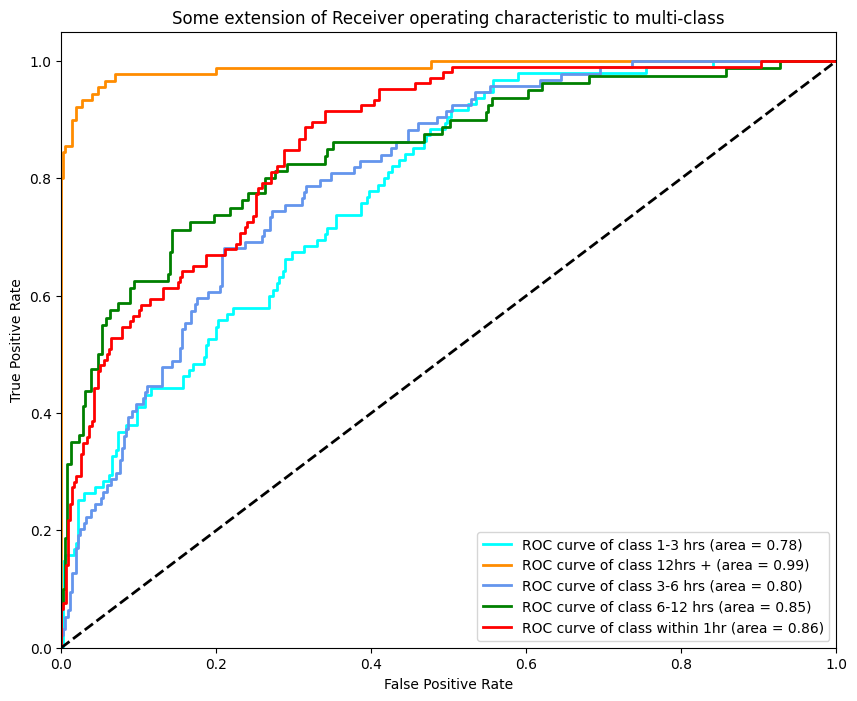

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Get class labels
classes = pipeline.classes_

# Binarize the output
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]

# Get prediction probabilities
y_score = pipeline.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()

In [ ]:
feature_importances_df = pd.DataFrame(
    pipeline.named_steps["model"].feature_importances_,
    index=pipeline.named_steps["prep"].get_feature_names_out(),
    columns=["Importance"],
)
feature_importances_df

,Importance
num__temperature,0.145008
num__distance,0.153851
num__fillLevel,0.265306
num__Lat,0.000000
num__Long,0.000000
num__month,0.085666
num__hour,0.083895
num__day_of_week,0.026302
num__is_weekend,0.005223
num__gas_sensor,0.073174


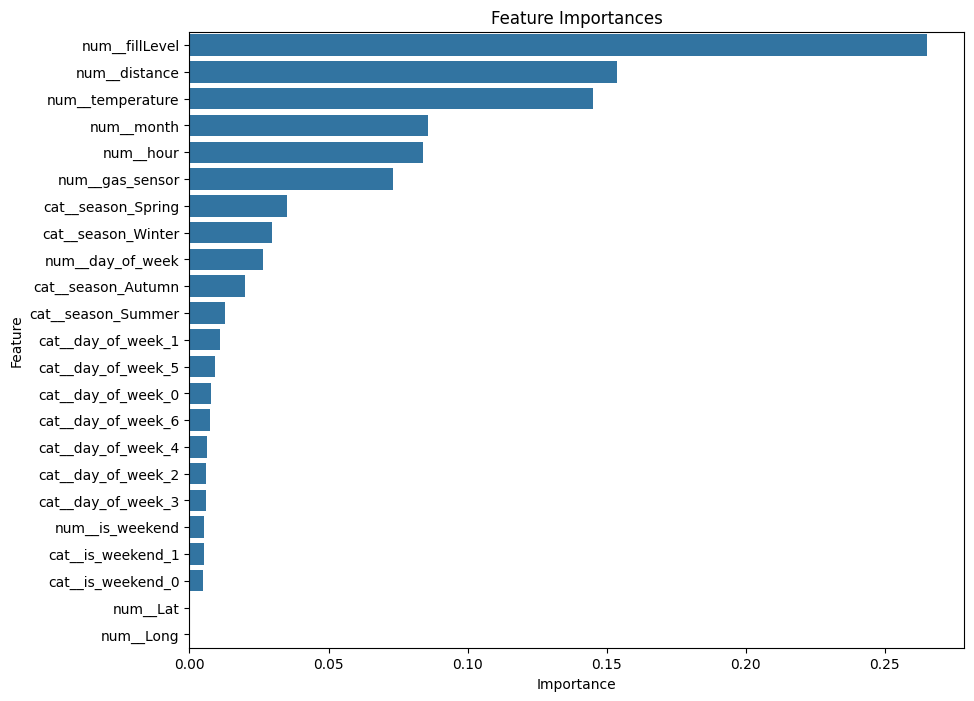

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the feature importances in descending order
feature_importances_df_sorted = feature_importances_df.sort_values(by='Importance', ascending=False)

# Create a horizontal bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y=feature_importances_df_sorted.index, data=feature_importances_df_sorted)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
confusion_matrix = pd.crosstab(y_test, pipeline.predict(X_test), rownames=['Actual'], colnames=['Predicted'])
confusion_matrix

Predicted,1-3 hrs,12hrs +,3-6 hrs,6-12 hrs,within 1hr
Actual,,,,,
1-3 hrs,457,0,10,5,33
12hrs +,2,480,0,19,2
3-6 hrs,55,0,383,25,18
6-12 hrs,20,1,10,440,19
within 1hr,40,0,8,1,437


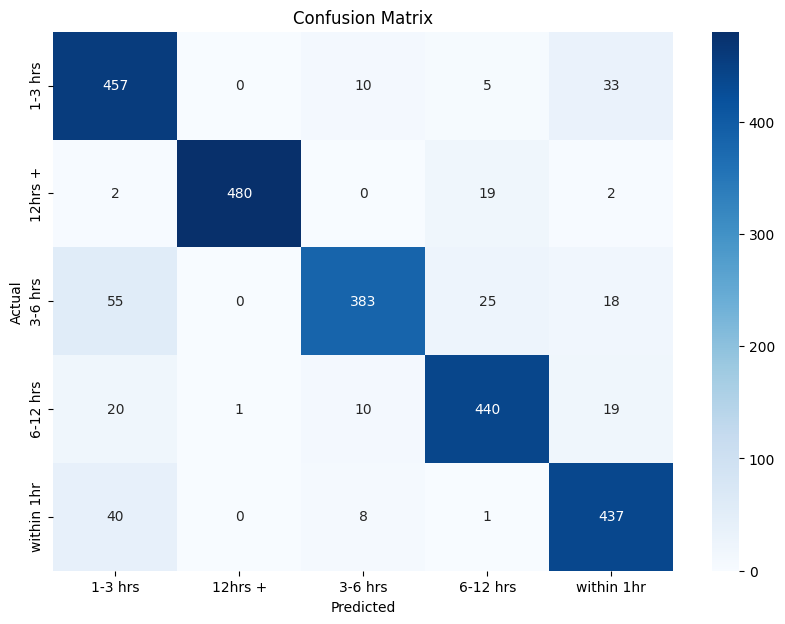

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:

#joblib.dump(pipeline, "bin_urgency_rf_pipeline.pkl")

['bin_urgency_rf_pipeline.pkl']

In [ ]:
"""

binID
:
"BIN_001"
binStatus
:
"NORMAL_GAS_ALERT"
distanceFromSensor
:
48.994
fillLevel
:
0
gasLevel
:
511
gpsStatus
:
"GPS Not Ready"
lastUpdated
:
111081
latitude
:
0
longitude
:
0
readableTime
:
"2025-07-17 18:36:56"
timestamp
:
111081


"""

In [ ]:
df.describe()

,temperature,distance,fillLevel,Lat,Long,distance_percentage,month,hour,day_of_week,is_weekend,gas_sensor
count,12325.000000,12325.000000,12325.000000,1.232500e+04,1.232500e+04,12325.000000,12325.000000,12325.000000,12325.000000,12325.000000,12325.000000
mean,18.087732,333.050791,79.217120,-3.780000e+01,1.449700e+02,16.652540,7.147262,11.400243,2.953509,0.302880,50.065580
std,5.912110,207.282534,12.162753,7.787864e-12,2.367624e-11,10.364127,3.307679,7.157412,2.108628,0.459523,28.544976
min,2.900000,199.000000,46.000000,-3.780000e+01,1.449700e+02,9.950000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,14.200000,200.000000,68.000000,-3.780000e+01,1.449700e+02,10.000000,5.000000,5.000000,1.000000,0.000000,25.400000
50%,17.900000,203.000000,86.000000,-3.780000e+01,1.449700e+02,10.150000,7.000000,11.000000,3.000000,0.000000,51.260000
75%,22.400000,355.000000,89.000000,-3.780000e+01,1.449700e+02,17.750000,10.000000,18.000000,5.000000,1.000000,74.150000
max,47.100000,928.000000,90.000000,-3.780000e+01,1.449700e+02,46.400000,12.000000,23.000000,6.000000,1.000000,99.960000


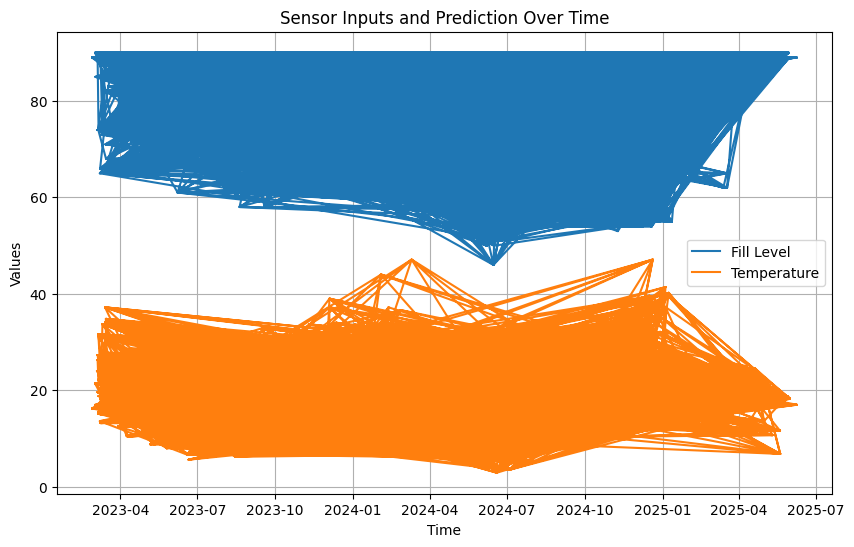

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("new_data_augmented.csv")
df['time'] = pd.to_datetime(df['time'])

plt.figure(figsize=(10, 6))
plt.plot(df['time'], df['fillLevel'], label='Fill Level')
plt.plot(df['time'], df['temperature'], label='Temperature')
plt.legend()
plt.title('Sensor Inputs and Prediction Over Time')
plt.xlabel('Time')
plt.ylabel('Values')
plt.grid(True)
plt.show()

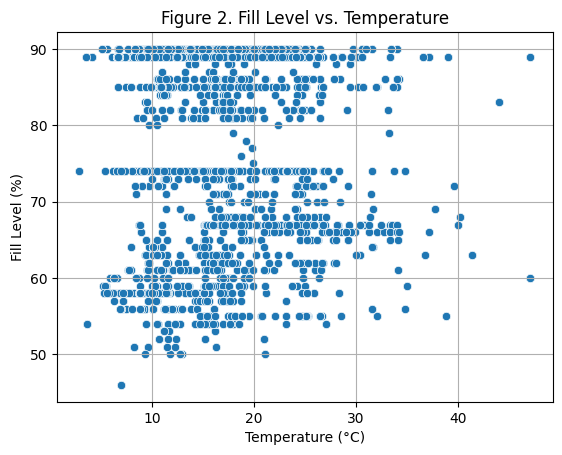

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='temperature', y='fillLevel')
plt.title('Figure 2. Fill Level vs. Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Fill Level (%)')
plt.grid(True)
plt.show()


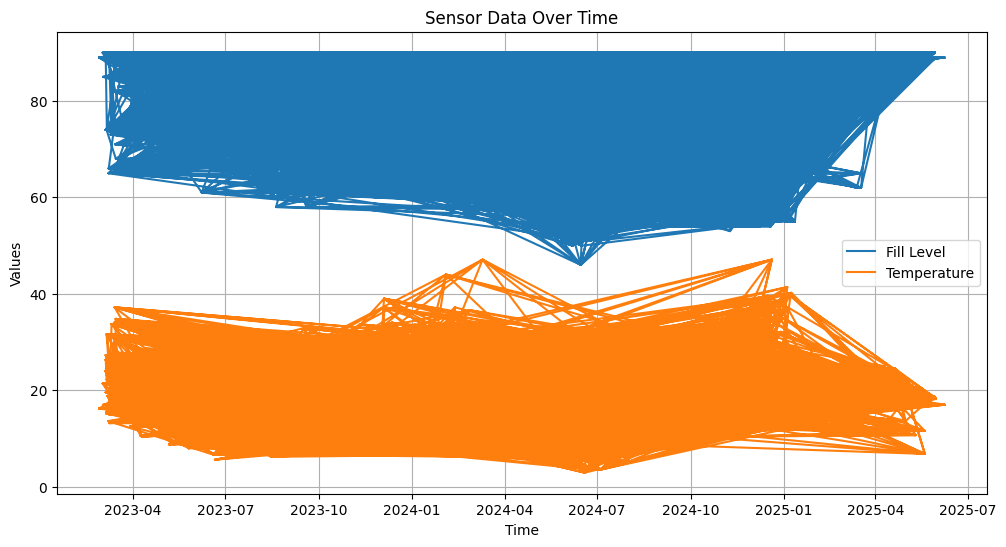

In [ ]:
df['time'] = pd.to_datetime(df['time'])

plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['fillLevel'], label='Fill Level')
plt.plot(df['time'], df['temperature'], label='Temperature')
plt.legend()
plt.title('Sensor Data Over Time')
plt.xlabel('Time')
plt.ylabel('Values')
plt.grid(True)
plt.show()

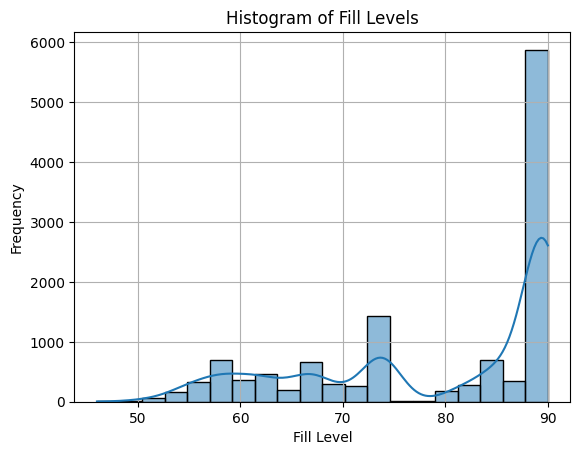

In [ ]:
sns.histplot(df['fillLevel'], bins=20, kde=True)
plt.title('Histogram of Fill Levels')
plt.xlabel('Fill Level')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

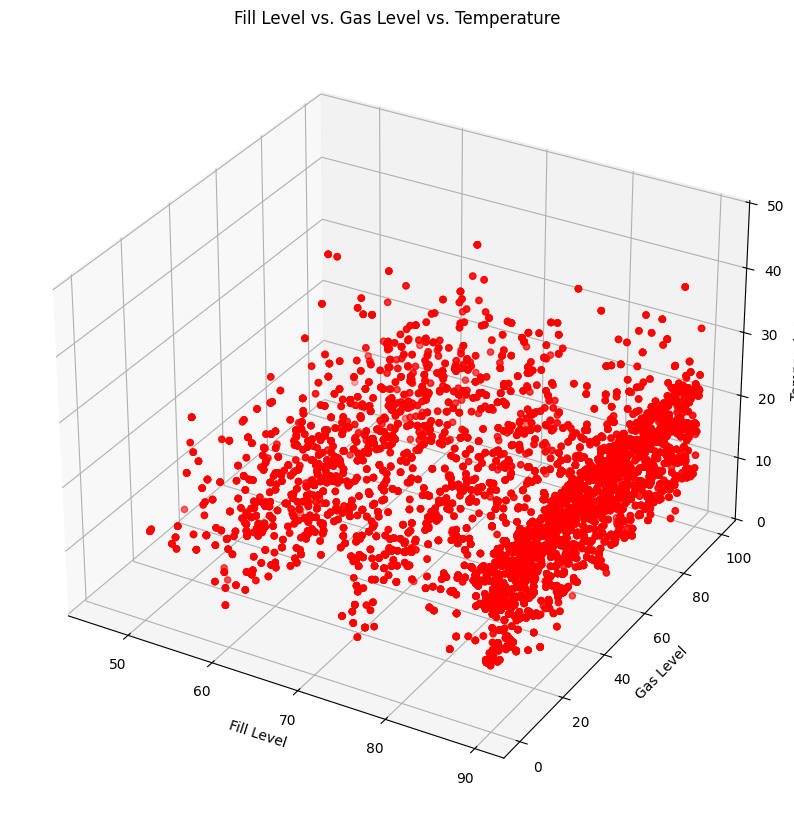

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['fillLevel'], df['gas_sensor'], df['temperature'], c='r', marker='o')
ax.set_xlabel('Fill Level')
ax.set_ylabel('Gas Level')
ax.set_zlabel('Temperature')
plt.title('Fill Level vs. Gas Level vs. Temperature')
plt.show()

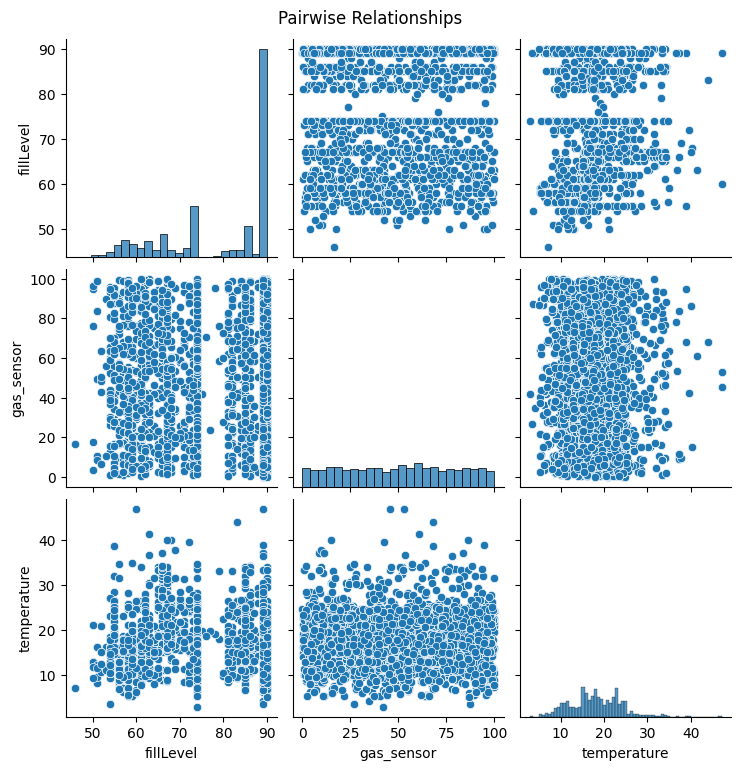

In [ ]:
sns.pairplot(df[['fillLevel', 'gas_sensor', 'temperature']])
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

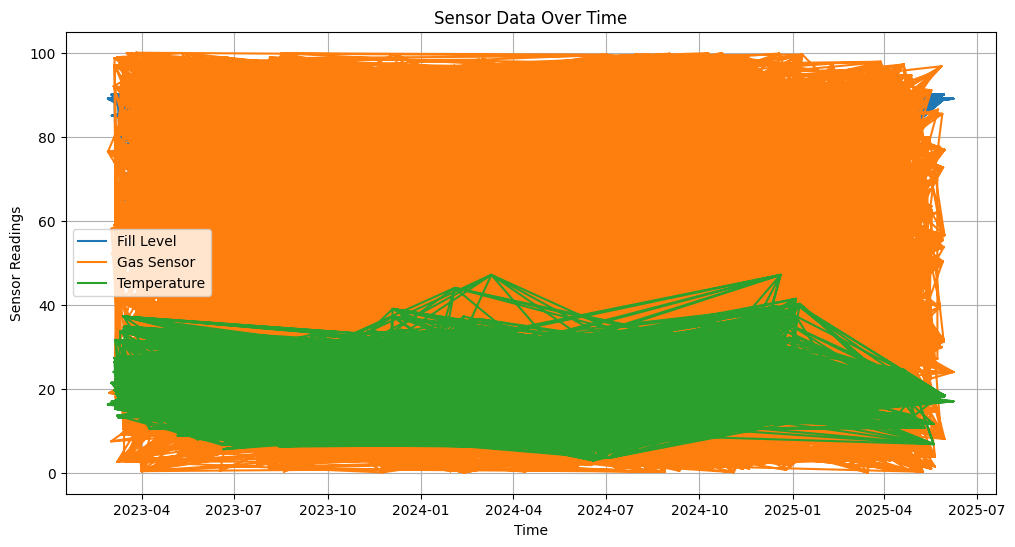

In [ ]:
df['time'] = pd.to_datetime(df['time'])

plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['fillLevel'], label='Fill Level')
plt.plot(df['time'], df['gas_sensor'], label='Gas Sensor')
plt.plot(df['time'], df['temperature'], label='Temperature')
plt.legend()
plt.title('Sensor Data Over Time')
plt.xlabel('Time')
plt.ylabel('Sensor Readings')
plt.grid(True)
plt.show()


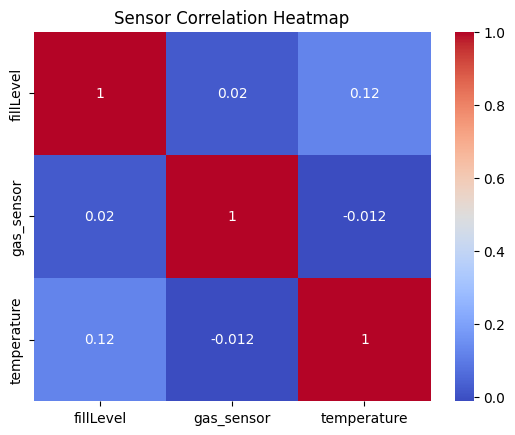

In [ ]:
corr = df[['fillLevel', 'gas_sensor', 'temperature']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Sensor Correlation Heatmap')
plt.show()

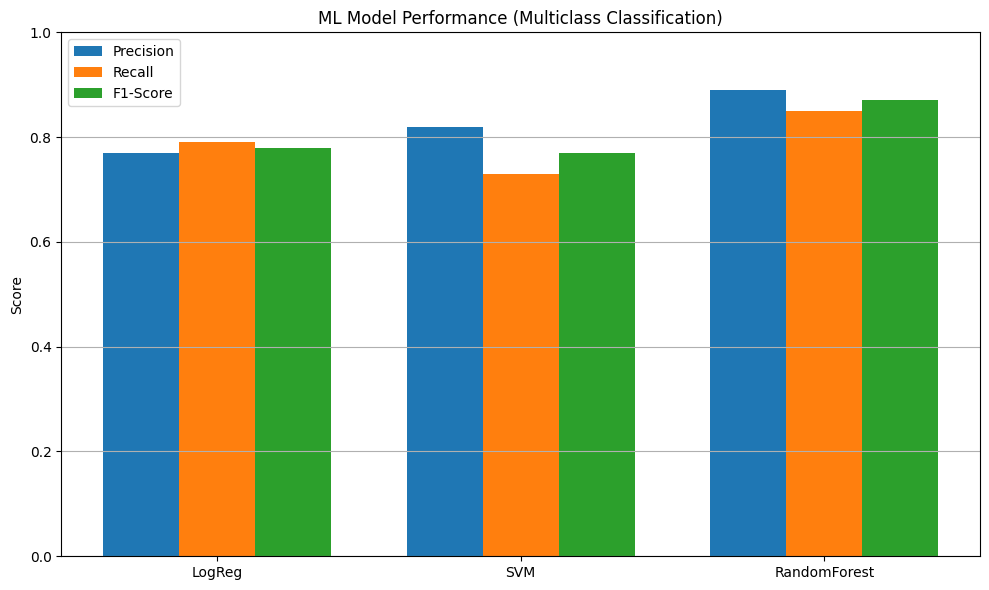

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['LogReg', 'SVM', 'RandomForest']
precision = [0.77, 0.82, 0.89]
recall =    [0.79, 0.73, 0.85]
f1_score =  [0.78, 0.77, 0.87]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score, width, label='F1-Score')

plt.ylabel('Score')
plt.title('ML Model Performance (Multiclass Classification)')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

